# ***IMPORT DATASET & LIBRARIES***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("StudentsPerformance.csv")


In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0,218.0,72.666667
1,female,group C,some college,standard,completed,69.0,90.0,88.0,247.0,82.333333
2,female,group B,master's degree,standard,none,90.0,95.0,93.0,278.0,92.666667
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,44.0,148.0,49.333333
4,male,group C,some college,standard,none,76.0,78.0,75.0,229.0,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88.0,99.0,95.0,282.0,94.000000
996,male,group C,high school,free/reduced,none,62.0,55.0,55.0,172.0,57.333333
997,female,group C,high school,free/reduced,completed,59.0,71.0,65.0,195.0,65.000000
998,female,group D,some college,standard,completed,68.0,78.0,77.0,223.0,74.333333


In [ ]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


# ***DATASET EXPLORATION***

In [ ]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.shape
print(f"The dataset has {df.shape[0]} data points and {df.shape[1]} columns")

The dataset has 1000 data points and 8 columns


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


*The dataset has no null values✌️*

In [ ]:
df.duplicated().sum()

np.int64(0)

*The dataset has no duplicate values present👍*

# *DATA VISUALIZATION*

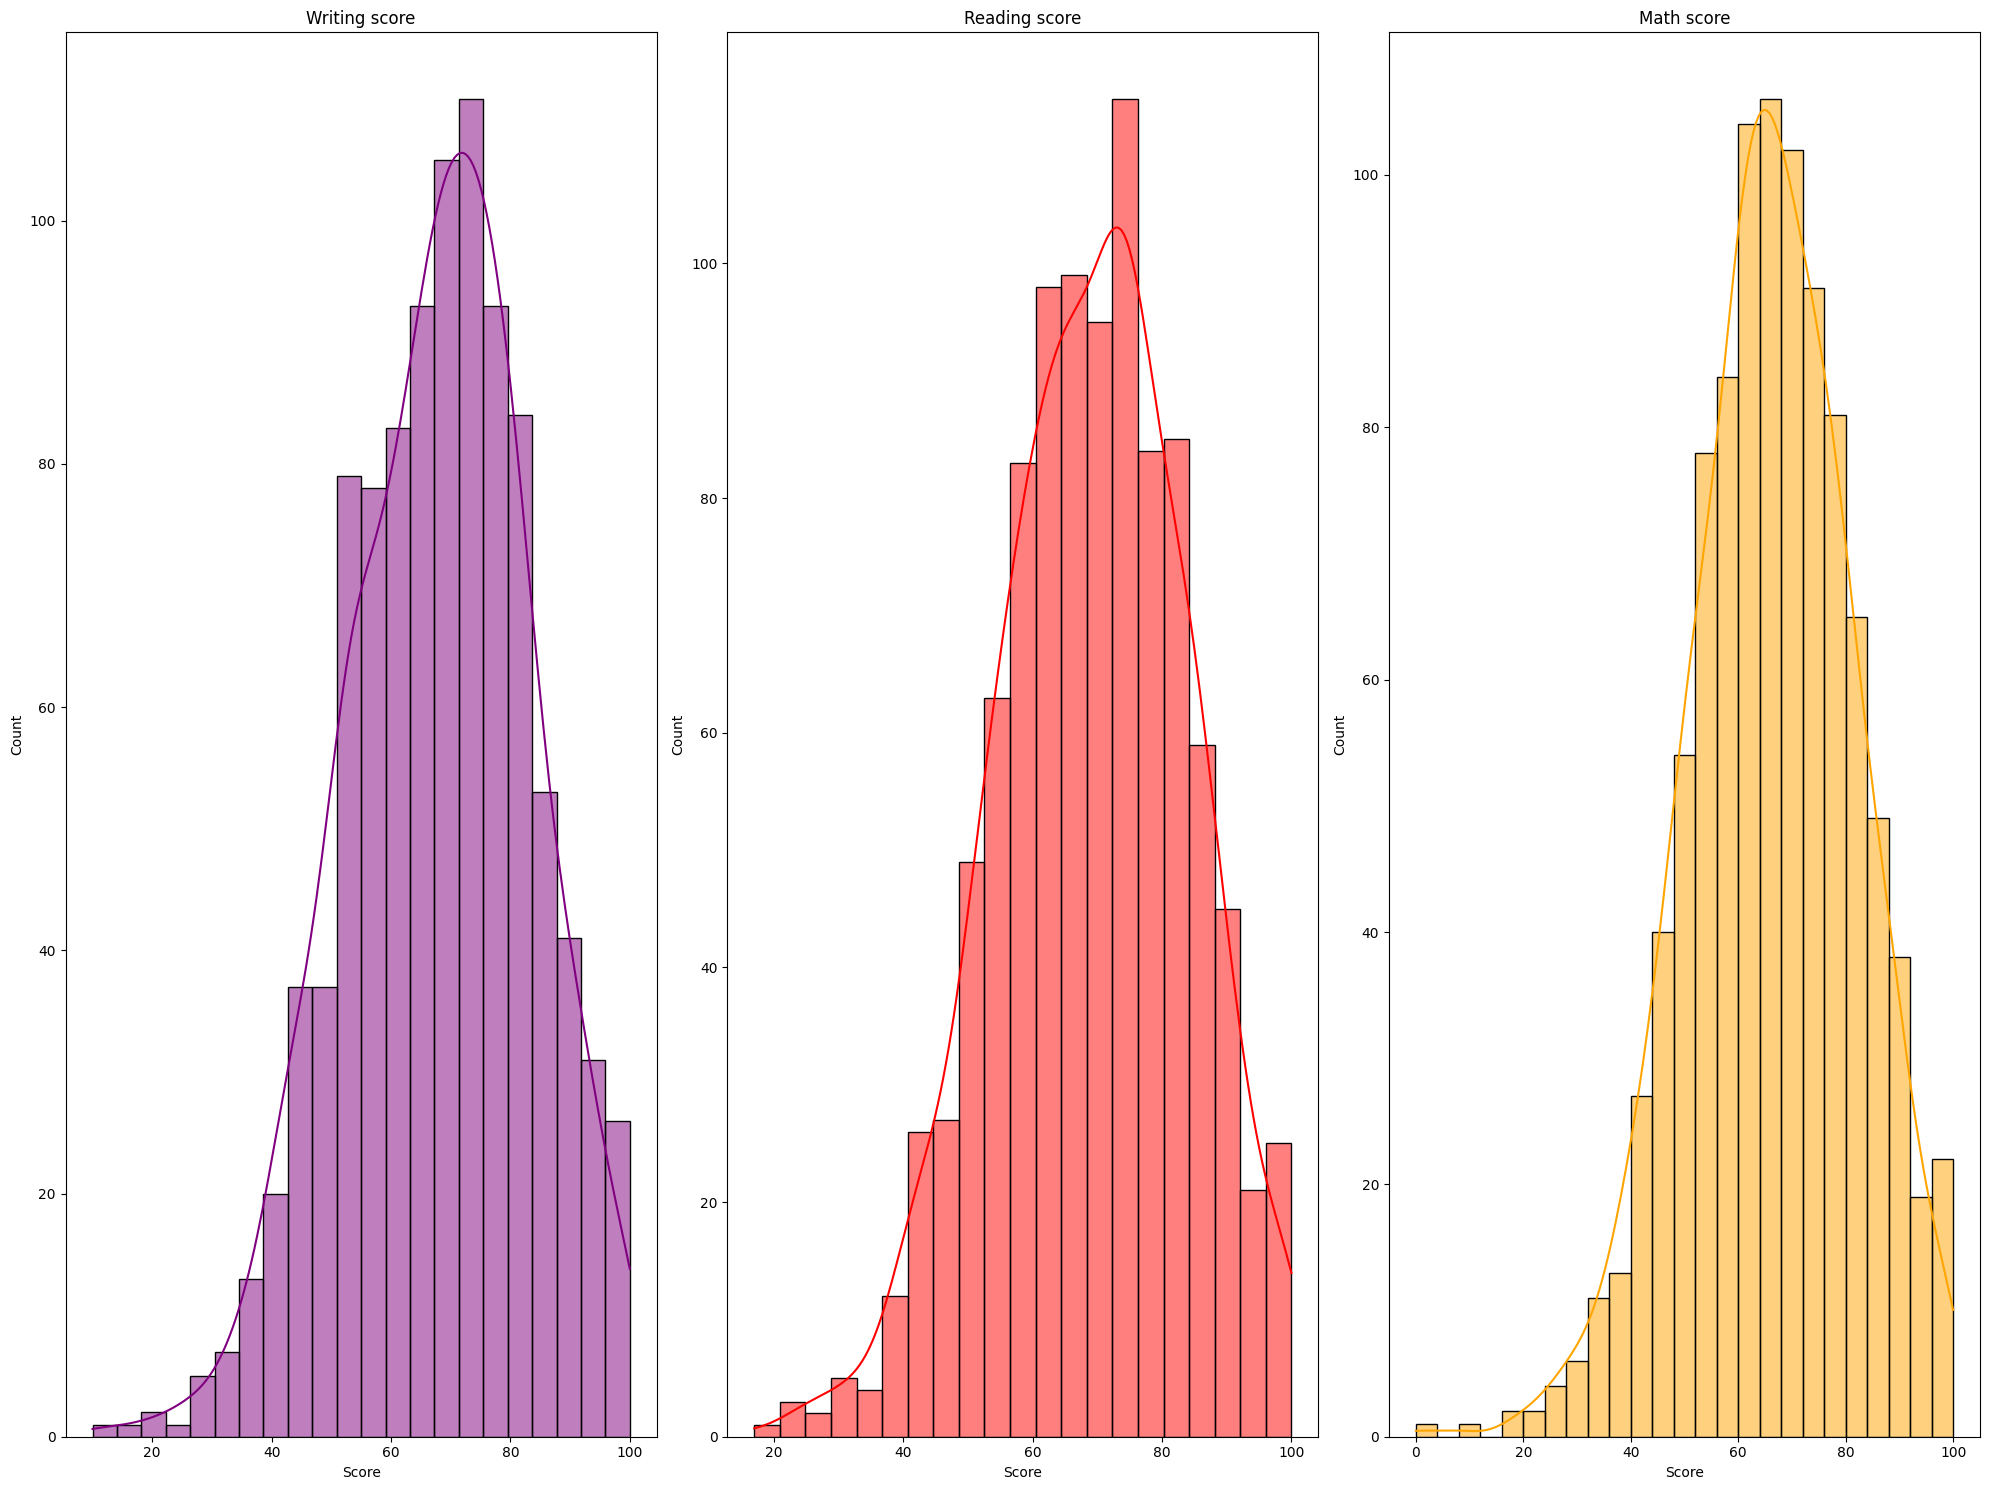

In [ ]:
#histogram plots
fig,axs=plt.subplots(1,3,figsize=(20,15))

sns.histplot(df['writing score'],ax=axs[0],color='Purple',kde=True)
axs[0].set_title('Writing score')
axs[0].set_xlabel('Score')
axs[0].set_ylabel('Count')

sns.histplot(df['reading score'],ax=axs[1],color='Red',kde=True)
axs[1].set_title('Reading score')
axs[1].set_xlabel('Score')
axs[1].set_ylabel('Count')

sns.histplot(df['math score'],ax=axs[2],color='Orange',kde=True)
axs[2].set_title('Math score')
axs[2].set_xlabel('Score')
axs[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

INSIGHT:

*Scores are slightly left skewed with most students scoring between 60 to 80 marks*

# Removing Outliers

In [ ]:
gender_wise_math_score=df.groupby('gender')['math score'].median()
gender_wise_math_score

,math score
gender,
female,65.0
male,69.0


In [ ]:
#math score mean
math_score_mean=df['math score'].mean()
math_score_mean


#math score median
math_score_median=df['math score'].median()
math_score_median

#math score mode
math_score_mode=df['math score'].mode()
math_score_mode

#standard_Deviation
math_score_std=df['math score'].std()
math_score_std

#maximum
max_math_score=df['math score'].max()
max_math_score

#minimum
min_math_score=df['math score'].min()
min_math_score

#First quartile(Q1) and third quartile(Q3)
Q1 = math_score_mean - 3 * math_score_std
Q3 = math_score_mean + 3 * math_score_std
print(Q1,Q3)

20.599759711971593 111.57824028802841


In [ ]:
df[(df['math score']<Q1) | (df['math score']>Q3)]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
787,female,group B,some college,standard,none,19,38,32
980,female,group B,high school,free/reduced,none,8,24,23


In [ ]:
df['math score'] = df.apply(lambda x :gender_wise_math_score[x['gender']] if x['math score'] < Q1 else x['math score'], axis = 1)


In [ ]:
gender_wise_reading_score=df.groupby('gender')['reading score'].median()
gender_wise_reading_score

,reading score
gender,
female,73.0
male,66.0


In [ ]:
#reading score mean
reading_score_mean=df['reading score'].mean()

#reading score median
reading_score_median=df['reading score'].median()


#reading score mode
reading_score_mode=df['reading score'].mode()


#standard_Deviation
reading_score_std=df['reading score'].std()

#maximum
max_reading_score=df['reading score'].max()


#minimum
min_reading_score=df['reading score'].min()


#First quartile(Q1) and third quartile(Q3)
Q1 = reading_score_mean - 3 * reading_score_std
Q3 = reading_score_mean + 3 * reading_score_std
print(Q1,Q3)

25.36842418824334 112.96957581175666


In [ ]:
df[(df['reading score']<Q1) | (df['reading score']>Q3)]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,65.0,17,10
327,male,group A,some college,free/reduced,none,28.0,23,19
596,male,group B,high school,free/reduced,none,30.0,24,15
980,female,group B,high school,free/reduced,none,65.0,24,23


In [ ]:
df['reading score'] = df.apply(lambda x :gender_wise_reading_score[x['gender']] if x['reading score'] < Q1 else x['reading score'], axis = 1)


In [ ]:
gender_wise_writing_score=df.groupby('gender')['writing score'].median()
gender_wise_writing_score

,writing score
gender,
female,74.0
male,64.0


In [ ]:
#writing score mean
writing_score_mean=df['writing score'].mean()

#writing score median
writing_score_median=df['writing score'].median()

#writing score mode
writing_score_mode=df['writing score'].mode()


#standard_Deviation
writing_score_std=df['writing score'].std()

#maximum
max_writing_score=df['writing score'].max()


#minimum
min_writing_score=df['writing score'].min()


#First quartile(Q1) and third quartile(Q3)
Q1 = writing_score_mean - 3 * writing_score_std
Q3 = writing_score_mean + 3 * writing_score_std
print(Q1,Q3)

22.467028967391073 113.64097103260893


In [ ]:
df[(df['writing score']<Q1) | (df['writing score']>Q3)]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,65.0,73.0,10
76,male,group E,some high school,standard,none,30.0,26.0,22
327,male,group A,some college,free/reduced,none,28.0,66.0,19
596,male,group B,high school,free/reduced,none,30.0,66.0,15


In [ ]:
df['writing score'] = df.apply(lambda x :gender_wise_writing_score[x['gender']] if x['writing score'] < Q1 else x['writing score'], axis = 1)


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.30400,69.359000,68.254000
std,14.75104,14.291129,14.840139
min,22.00000,26.000000,23.000000
25%,57.00000,59.750000,58.000000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


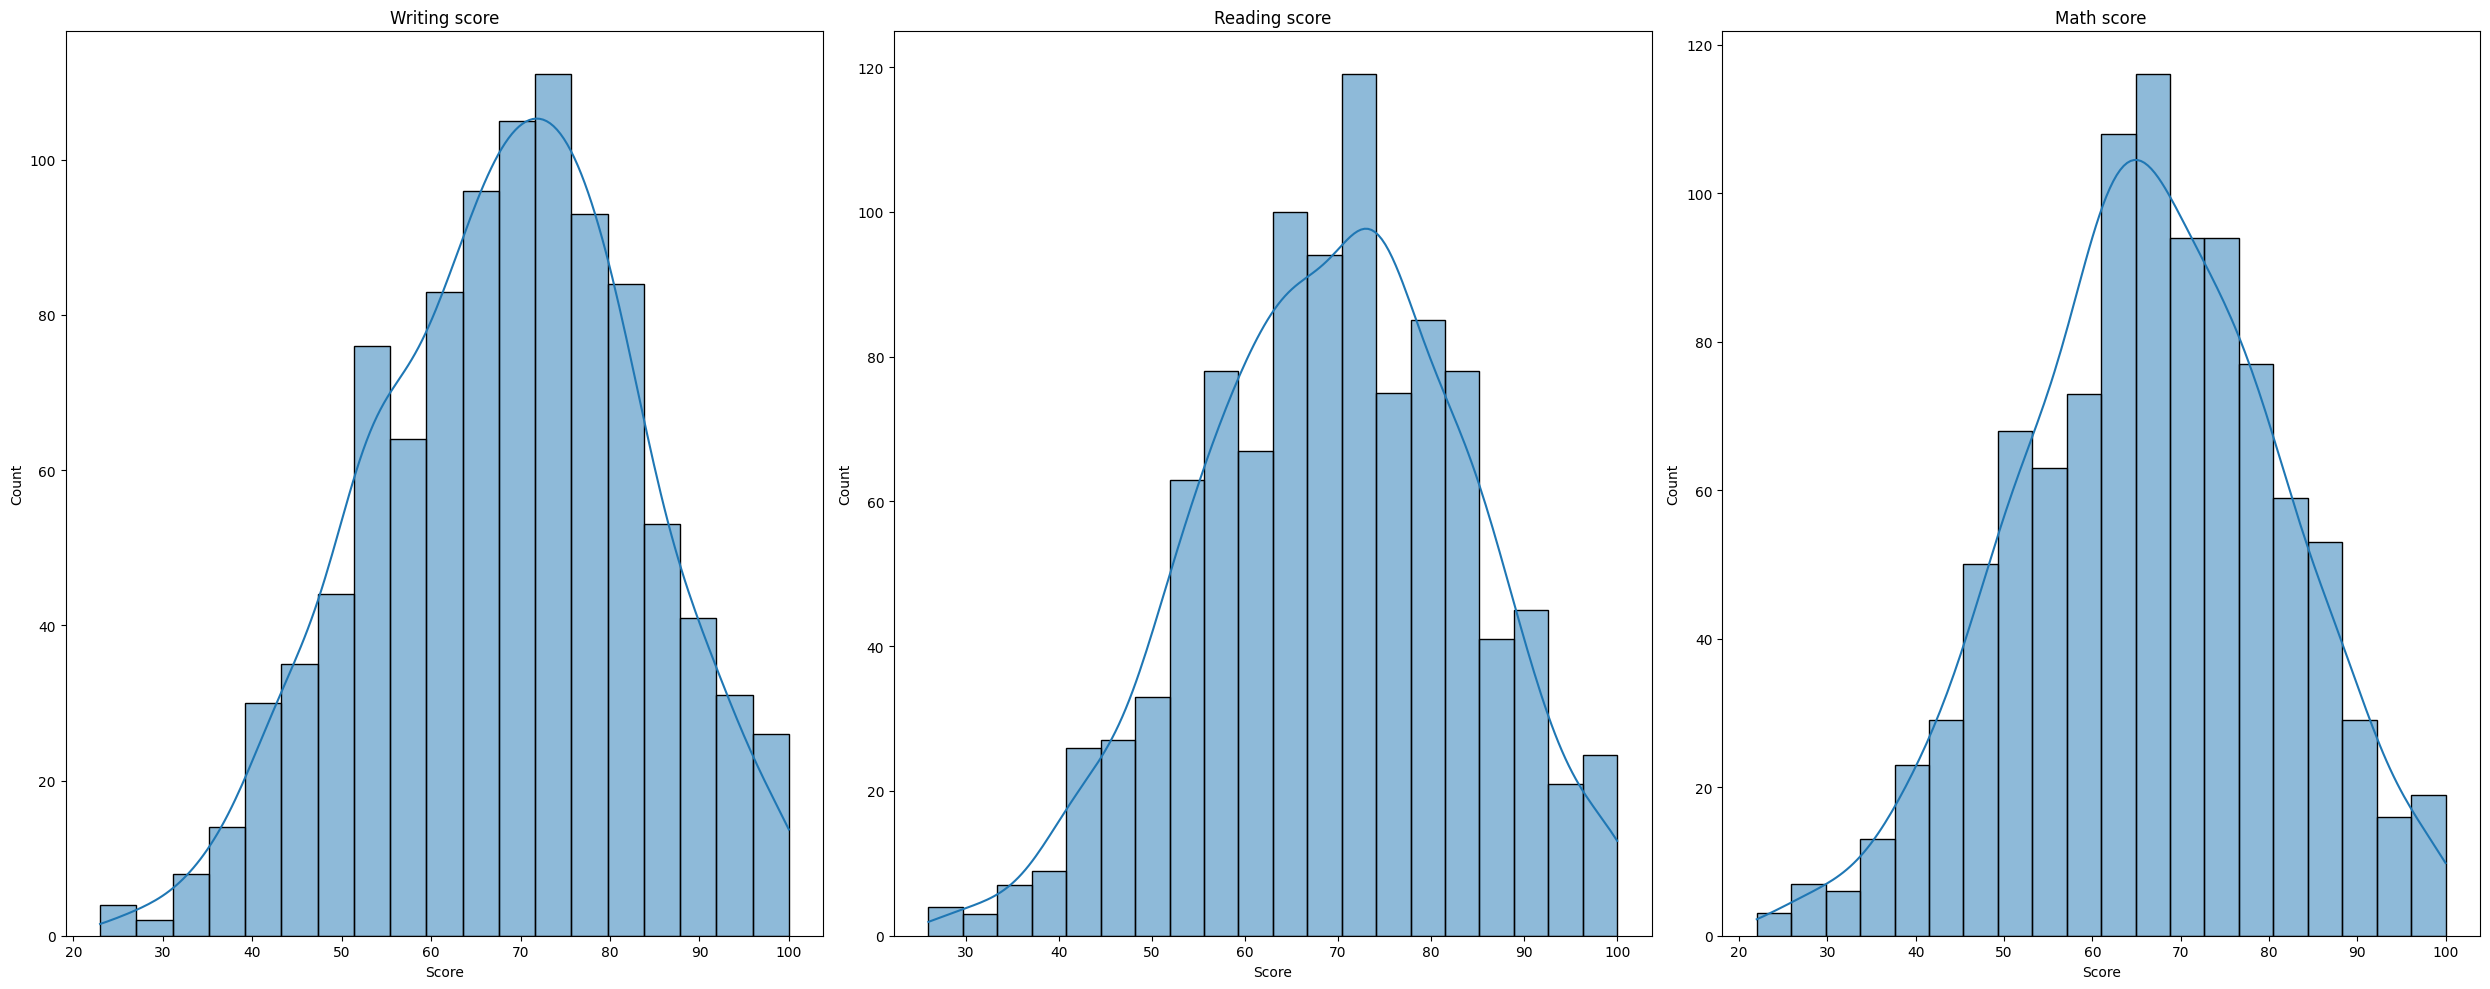

In [ ]:
#histogram plots
fig,axs=plt.subplots(1,3,figsize=(25,10))

sns.histplot(df['writing score'],ax=axs[0],kde=True)
axs[0].set_title('Writing score')
axs[0].set_xlabel('Score')
axs[0].set_ylabel('Count')

sns.histplot(df['reading score'],ax=axs[1],kde=True)
axs[1].set_title('Reading score')
axs[1].set_xlabel('Score')
axs[1].set_ylabel('Count')

sns.histplot(df['math score'],ax=axs[2],kde=True)
axs[2].set_title('Math score')
axs[2].set_xlabel('Score')
axs[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
num_columns=df.select_dtypes(include=np.number).shape[1]
cat_columns=df.select_dtypes(exclude=np.number).shape[1]

print(f"This dataset has {num_columns} numerical columns and {cat_columns} categorical columns")

This dataset has 3 numerical columns and 5 categorical columns


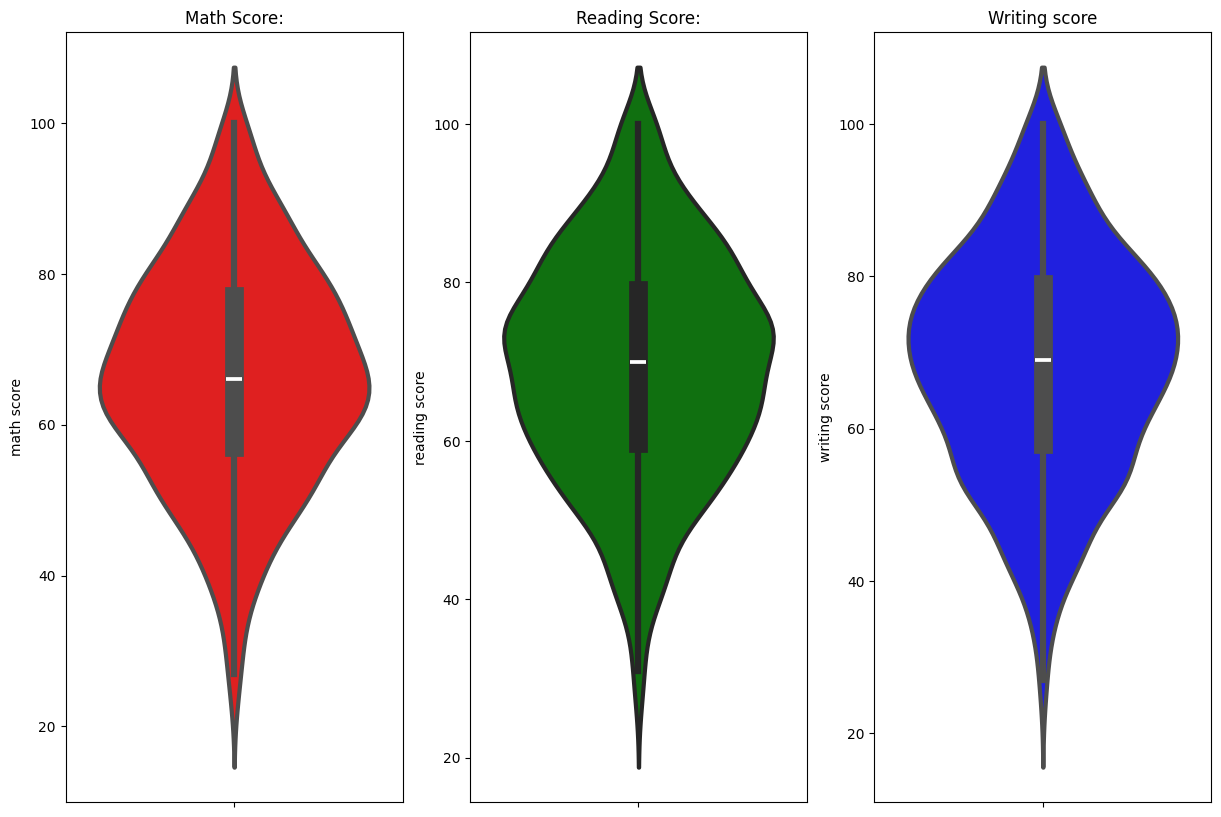

In [ ]:
plt.figure(figsize=(20,10))


plt.subplot(1,4,1)
plt.title("Math Score:")
sns.violinplot(y='math score',data=df,color='red',linewidth=3)

plt.subplot(1,4,2)
plt.title("Reading Score:")
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)

plt.subplot(1,4,3)
plt.title("Writing score")
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)

plt.show()

INSIGHT:

### *The graph shows that the students score between 60-80 in maths whereas score nearly 50-80 in reading and writing*

# *UNIVARIATE ANALYSIS*

Gender wise distribution

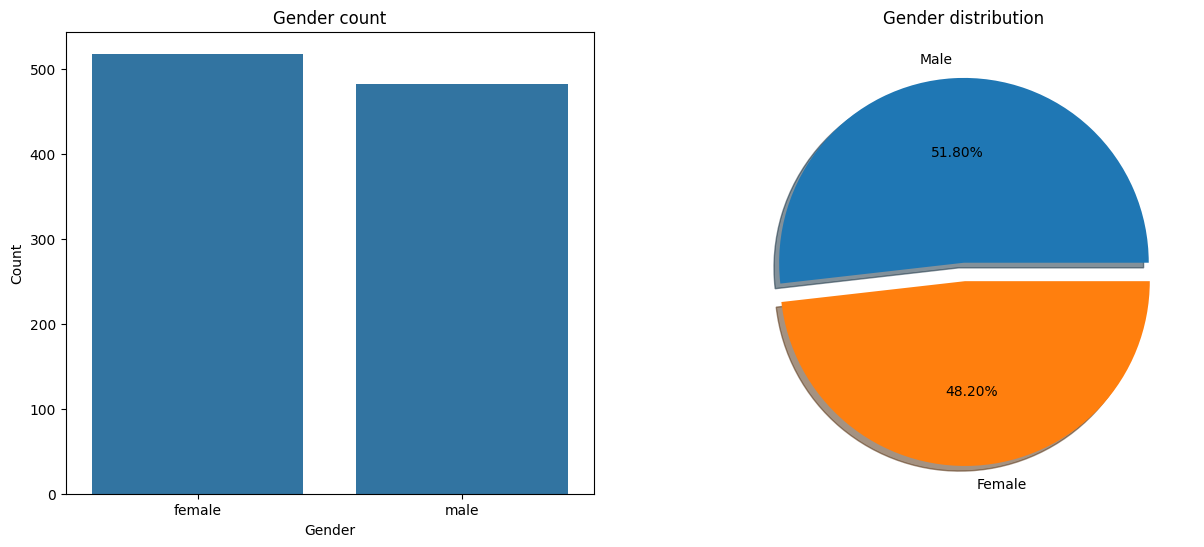

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(15,6))

sns.countplot(x='gender',data=df,ax=ax[0])
ax[0].set_title("Gender count")
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Count")



plt.subplot(1,2,2)
plt.pie(df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],shadow=True,autopct='%1.2f%%')
plt.title("Gender distribution")
plt.show()

INSIGHT:

# The data is balanced with nearly 51.8% male students and 48.2% female students

Group-Wise Distribution

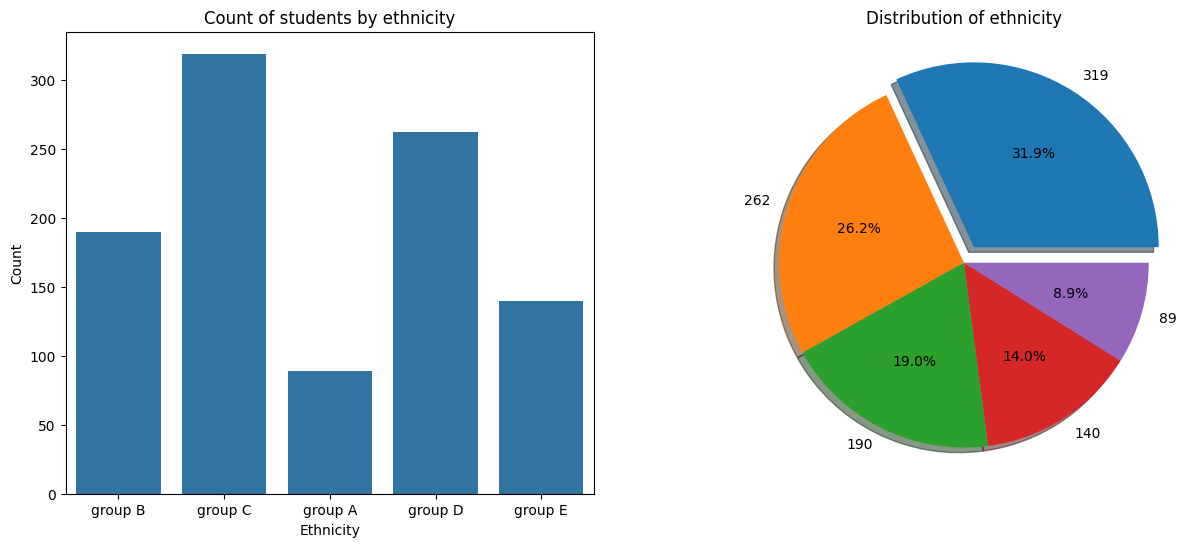

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(15,6))

sns.countplot(x=df['race/ethnicity'],data=df,ax=ax[0])
ax[0].set_title("Count of students by ethnicity")
ax[0].set_xlabel("Ethnicity")
ax[0].set_ylabel("Count")



plt.subplot(1,2,2)
plt.pie(x=df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts(),explode=[0.1,0,0,0,0],shadow=True,autopct='%1.1f%%')


plt.title("Distribution of ethnicity")
plt.show()

INSIGHT:

*The given charts show that group C has highest representation among students followed by D,B,E,A and  Group A constitutes very small proportion in the dataset*

# *Student's Parents Educational background*

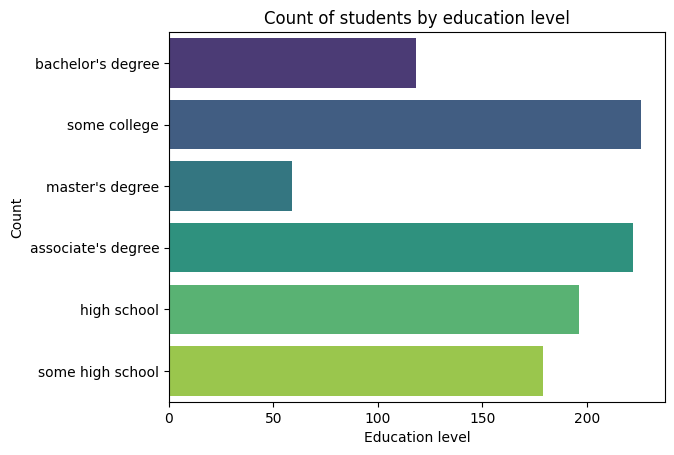

In [ ]:
fig=plt.plot(figsize=(20,5))


sns.countplot(df['parental level of education'],palette='viridis')
plt.title("Count of students by education level",fontweight='50',fontsize=12)
plt.xlabel("Education level")
plt.ylabel("Count")
plt.show()


INSIGHT:

### *The above bar chart shows that most of the parents have some college level of education or has a associate degree*

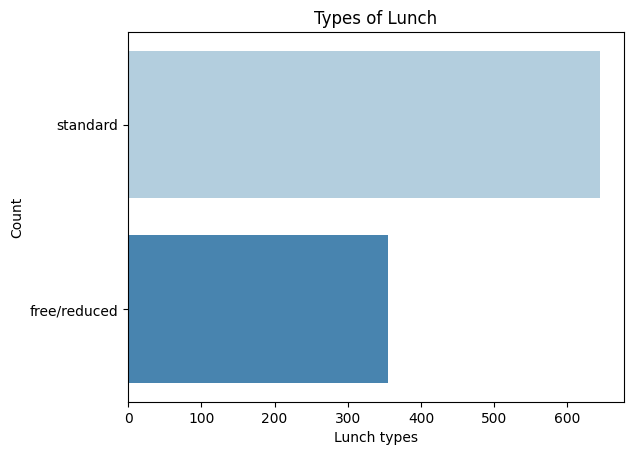

In [ ]:
fig=plt.plot(figsize=(20,5))


sns.countplot(df['lunch'],palette='Blues')
plt.title("Types of Lunch",fontweight='50',fontsize=12)
plt.xlabel("Lunch types")
plt.ylabel("Count")
plt.show()

# Bivariate Analysis


In [ ]:
df['total score']=df['math score'] + df['reading score'] + df['writing score']
df['average']=df['total score']/3
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0,218.0,72.666667
1,female,group C,some college,standard,completed,69.0,90.0,88.0,247.0,82.333333
2,female,group B,master's degree,standard,none,90.0,95.0,93.0,278.0,92.666667
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,44.0,148.0,49.333333
4,male,group C,some college,standard,none,76.0,78.0,75.0,229.0,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88.0,99.0,95.0,282.0,94.000000
996,male,group C,high school,free/reduced,none,62.0,55.0,55.0,172.0,57.333333
997,female,group C,high school,free/reduced,completed,59.0,71.0,65.0,195.0,65.000000
998,female,group D,some college,standard,completed,68.0,78.0,77.0,223.0,74.333333


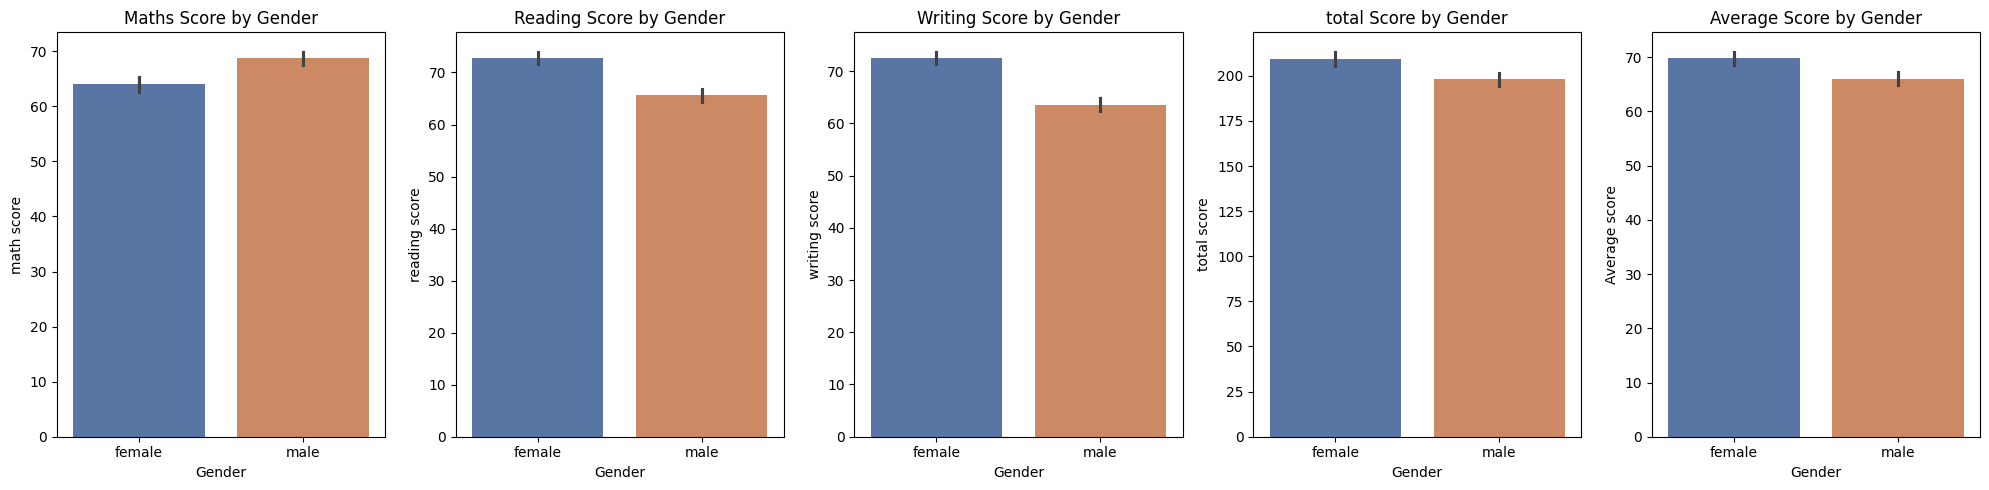

In [ ]:
fig,ax=plt.subplots(1,5,figsize=(20,5))


sns.barplot(x='gender',y='math score',data=df,ax=ax[0],palette='deep')
ax[0].set_title("Maths Score by Gender")
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("math score")


sns.barplot(x='gender',y='reading score',data=df,ax=ax[1],palette='deep')
ax[1].set_title("Reading Score by Gender")
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("reading score")

sns.barplot(x='gender',y='writing score',data=df,ax=ax[2],palette='deep')
ax[2].set_title("Writing Score by Gender")
ax[2].set_xlabel("Gender")
ax[2].set_ylabel("writing score")

sns.barplot(x='gender',y='total score',data=df,ax=ax[3],palette='deep')
ax[3].set_title("total Score by Gender")
ax[3].set_xlabel("Gender")
ax[3].set_ylabel("total score")

sns.barplot(x='gender',y='average',data=df,ax=ax[4],palette='deep')
ax[4].set_title("Average Score by Gender")
ax[4].set_xlabel("Gender")
ax[4].set_ylabel("Average score")

plt.tight_layout()
plt.show()


INSIGHT:

### Female students have slightly higher reading,writing,total and average scores than male students , The Male students only excel in maths

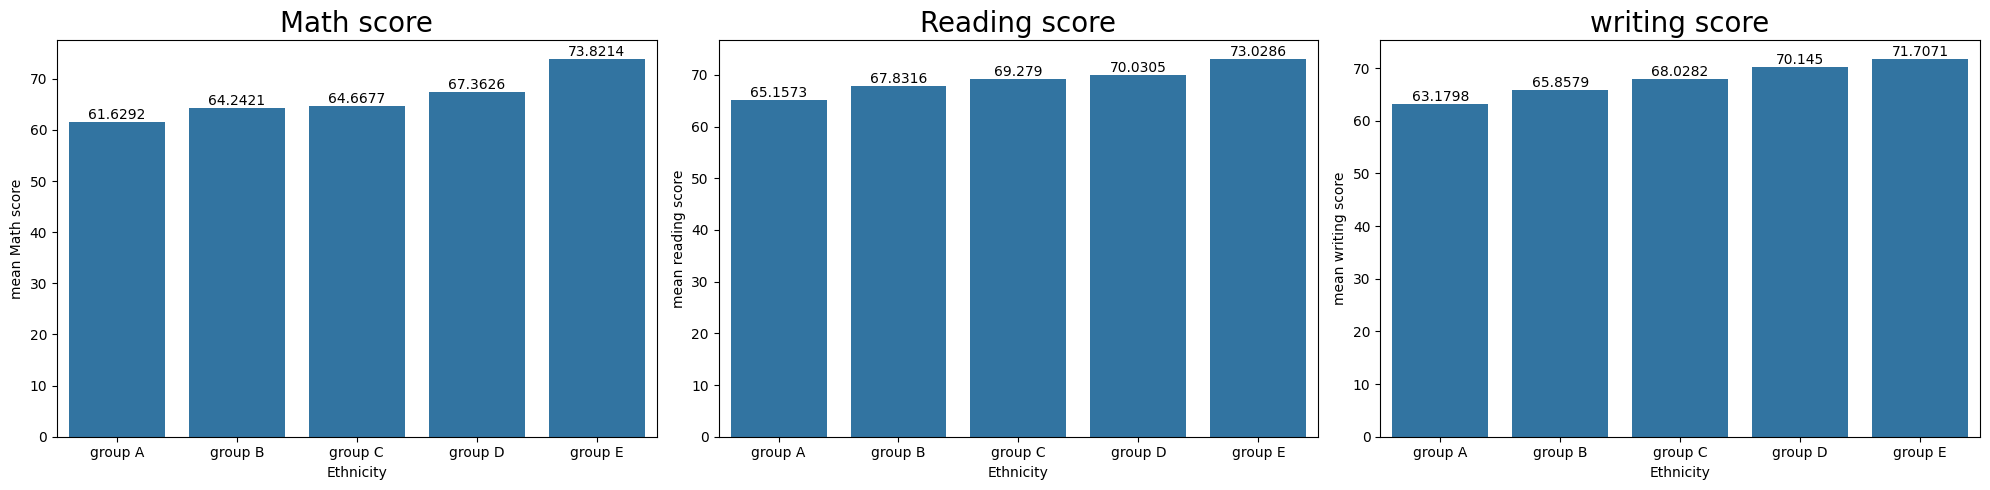

In [ ]:
grouped_data = df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score', 'total score', 'average']].mean()

fig,ax=plt.subplots(1,3,figsize=(20,5))

sns.barplot(x=grouped_data.index,y=grouped_data['math score'],ax=ax[0])
ax[0].set_title("Math score",size=20)
ax[0].set_xlabel("Ethnicity")
ax[0].set_ylabel("mean Math score")
ax[0].bar_label(ax[0].containers[0],size=10,color='black')


sns.barplot(x=grouped_data.index,y=grouped_data['reading score'],ax=ax[1])
ax[1].set_title("Reading score",size=20)
ax[1].set_xlabel("Ethnicity")
ax[1].set_ylabel("mean reading score")
ax[1].bar_label(ax[1].containers[0],size=10,color='black')

sns.barplot(x=grouped_data.index,y=grouped_data['writing score'],ax=ax[2])
ax[2].set_title("writing score",size=20)
ax[2].set_xlabel("Ethnicity")
ax[2].set_ylabel("mean writing score")
ax[2].bar_label(ax[2].containers[0],size=10,color='black')


plt.tight_layout()
plt.show()

Insights:

Math Score: Group E has the highest mean math score.


Reading Score: Group E has the highest mean reading score.

Writing Score: Group E has the highest mean writing score.

Group E consistently scores the highest in all subjects, while Group A scores the lowest across math, reading, and writing.

# Multivariate Analysis

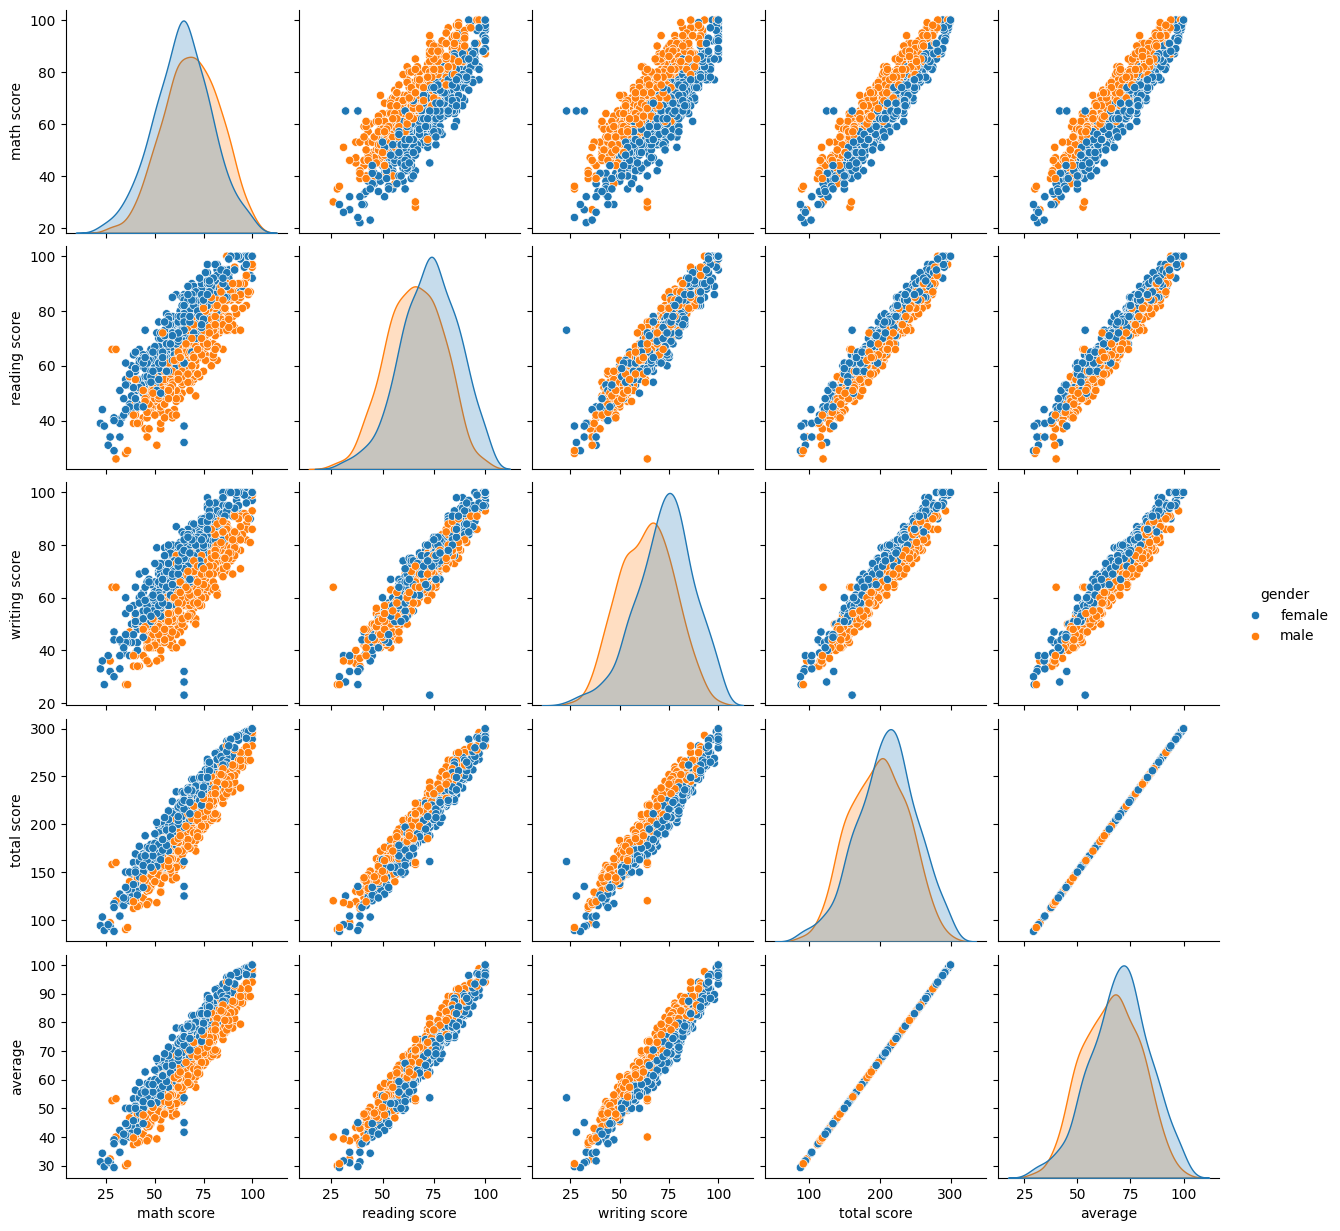

In [ ]:
sns.pairplot(df,hue='gender')
plt.show()

INSIGHT:

### The pairplot reveals that all the scores (math, reading, writing, total, and average) are positively correlated with each other, indicating that students who perform well in one subject tend to perform well in others.

PIEPLOT

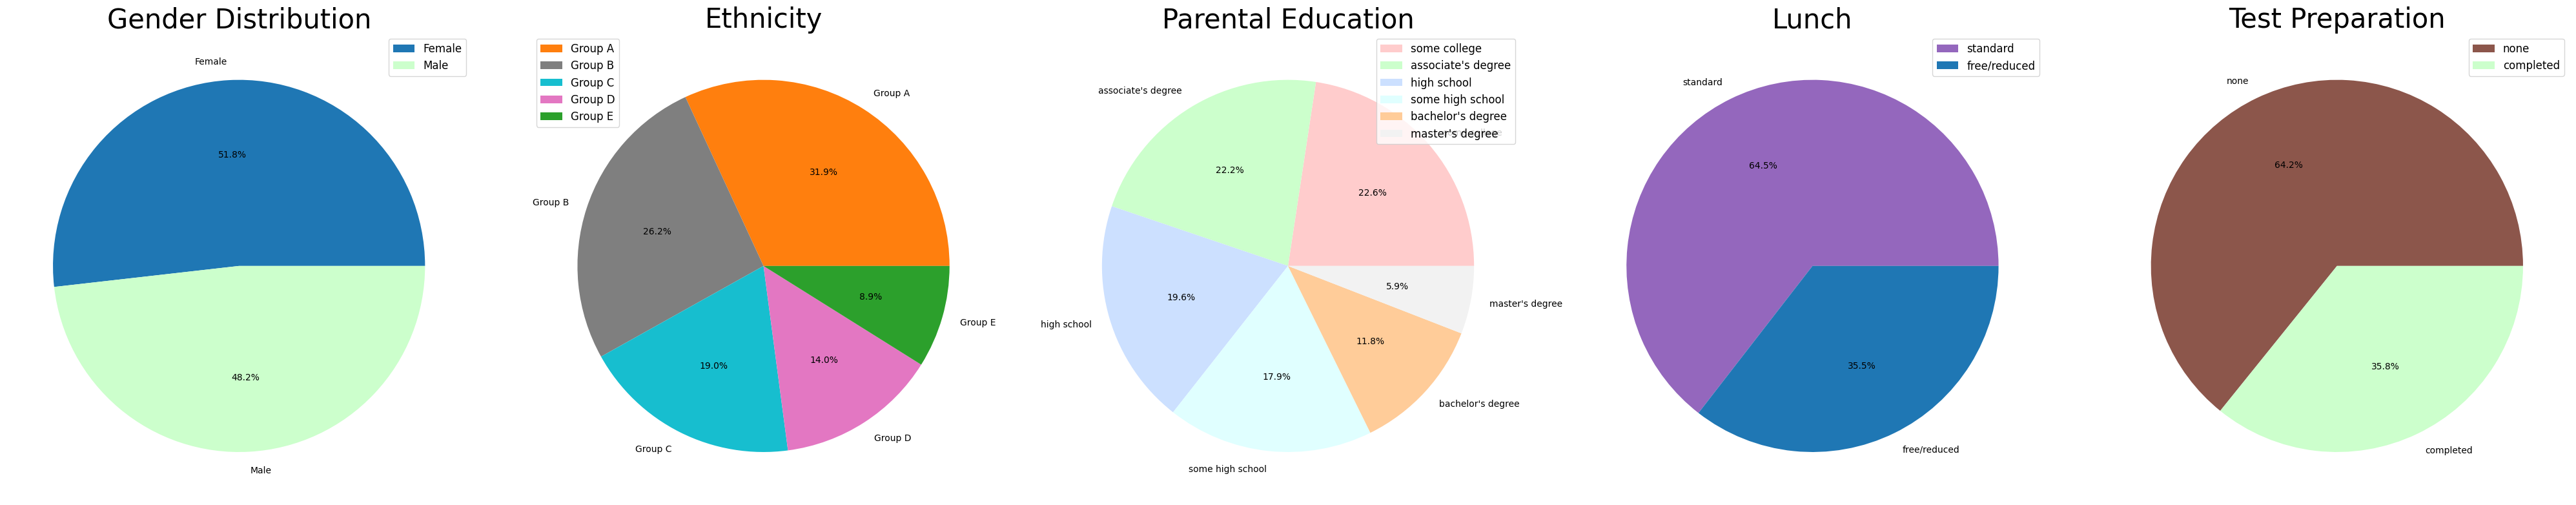

In [ ]:
fig = plt.figure(figsize=(40,30))

plt.subplot(1,5,1)
color=['#1f77b4','#ccffcc']
plt.pie(df['gender'].value_counts(),labels=['Female','Male'],autopct='%1.1f%%',colors=color)
plt.title("Gender Distribution",fontsize=30)
plt.axis('off')
plt.legend(fontsize='12')


plt.subplot(1,5,2)
color=['#ff7f0e','#7f7f7f','#17becf','#e377c2','#2ca02c']
plt.pie(df['race/ethnicity'].value_counts(),labels=['Group A','Group B','Group C','Group D','Group E'],autopct='%1.1f%%',colors=color)
plt.title('Ethnicity',fontsize=30)
plt.axis('off')
plt.legend(fontsize='12')

plt.subplot(1,5,3)
color=['#ffcccc', '#ccffcc', '#cce0ff', '#e0ffff', '#ffcc99', '#f2f2f2']
plt.pie(df['parental level of education'].value_counts(),labels=df['parental level of education'].value_counts().index,autopct='%1.1f%%',colors=color)
plt.title('Parental Education',fontsize=30)
plt.axis('off')
plt.legend(fontsize='12')


plt.subplot(1,5,4)
color=['#9467bd','#1f77b4']
plt.pie(df['lunch'].value_counts(),labels=df['lunch'].value_counts().index,autopct='%1.1f%%',colors=color)
plt.title('Lunch',fontsize=30)
plt.axis('off')
plt.legend(fontsize='12')


plt.subplot(1,5,5)
color=['#8c564b','#ccffcc']
plt.pie(df['test preparation course'].value_counts(),labels=df['test preparation course'].value_counts().index,autopct='%1.1f%%',colors=color)
plt.title('Test Preparation',fontsize=30)
plt.axis('off')
plt.legend(fontsize='12')
plt.tight_layout()
Iplt.show()

INSIGHTS:

Gender: The dataset has a slightly higher percentage of female students (51.8%)

Race/Ethnicity: Group C is the largest ethnic group (31.9%)

Lunch: A majority of students have standard lunch (64.5%)

Test Preparation Course: Most students did not complete the test preparation course (64.2%)

Parental Education: The most common parental education levels are some college (22.6%) and associate's degree (22.2%)

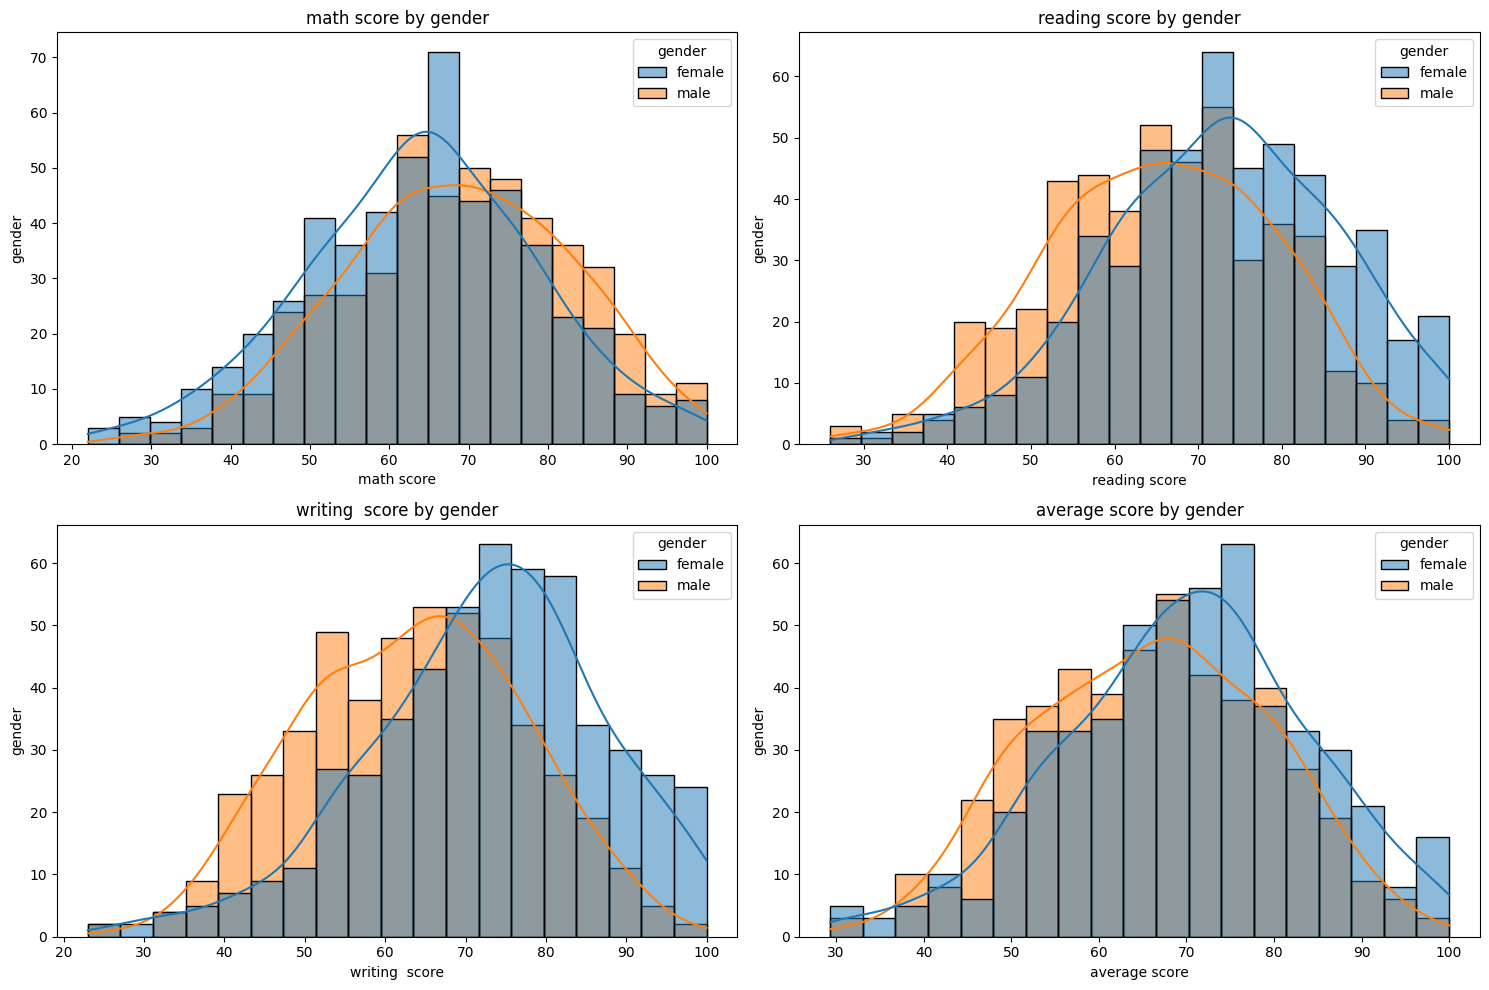

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(15,10))

sns.histplot(x=df['math score'],hue=df['gender'],kde=True,ax=ax[0,0])
ax[0,0].set_title('math score by gender')
ax[0,0].set_xlabel("math score")
ax[0,0].set_ylabel("gender")

sns.histplot(x=df['reading score'],hue=df['gender'],kde=True,ax=ax[0,1])
ax[0,1].set_title("reading score by gender")
ax[0,1].set_xlabel("reading score")
ax[0,1].set_ylabel("gender")


sns.histplot(x=df['writing score'],hue=df['gender'],kde=True,ax=ax[1,0])
ax[1,0].set_title("writing  score by gender")
ax[1,0].set_xlabel("writing  score")
ax[1,0].set_ylabel("gender")


sns.histplot(x=df['average'],hue=df['gender'],kde=True,ax=ax[1,1])
ax[1,1].set_title("average score by gender")
ax[1,1].set_xlabel("average score")
ax[1,1].set_ylabel("gender")

plt.tight_layout()
plt.show()


INSIGHT:

The distribution plots show that female students generally have higher and more concentrated scores in reading and writing, while male students have slightly higher math scores.

***Factors Influencing Performance:***

**Lunch, Race, and Parental Level of Education: These factors are significantly related to students' performance.**



**Gender Differences: Females tend to lead in pass percentages and are often the top scorers**